In [2]:
# Libraries used for data analysis, visualization and machine learning

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [3]:
# Read the advertising dataset

df = pd.read_csv('/content/Advertising.csv')

# Display first few records

df.head()

,Unnamed: 0,TV,Radio,Newspaper,Sales
0,1,230.1,37.8,69.2,22.1
1,2,44.5,39.3,45.1,10.4
2,3,17.2,45.9,69.3,9.3
3,4,151.5,41.3,58.5,18.5
4,5,180.8,10.8,58.4,12.9


In [4]:
# Check rows and columns

print("Dataset Shape:", df.shape)

# View column names

print("\nColumns:")
print(df.columns)

Dataset Shape: (200, 5)

Columns:
Index(['Unnamed: 0', 'TV', 'Radio', 'Newspaper', 'Sales'], dtype='object')


In [5]:
# Information about data types

df.info()

# Check missing values

df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  200 non-null    int64  
 1   TV          200 non-null    float64
 2   Radio       200 non-null    float64
 3   Newspaper   200 non-null    float64
 4   Sales       200 non-null    float64
dtypes: float64(4), int64(1)
memory usage: 7.9 KB


,0
Unnamed: 0,0
TV,0
Radio,0
Newspaper,0
Sales,0


In [6]:
# Summary statistics

df.describe()

,Unnamed: 0,TV,Radio,Newspaper,Sales
count,200.000000,200.000000,200.000000,200.000000,200.000000
mean,100.500000,147.042500,23.264000,30.554000,14.022500
std,57.879185,85.854236,14.846809,21.778621,5.217457
min,1.000000,0.700000,0.000000,0.300000,1.600000
25%,50.750000,74.375000,9.975000,12.750000,10.375000
50%,100.500000,149.750000,22.900000,25.750000,12.900000
75%,150.250000,218.825000,36.525000,45.100000,17.400000
max,200.000000,296.400000,49.600000,114.000000,27.000000


In [7]:
# Remove index column

df.drop('Unnamed: 0', axis=1, inplace=True)

df.head()

,TV,Radio,Newspaper,Sales
0,230.1,37.8,69.2,22.1
1,44.5,39.3,45.1,10.4
2,17.2,45.9,69.3,9.3
3,151.5,41.3,58.5,18.5
4,180.8,10.8,58.4,12.9


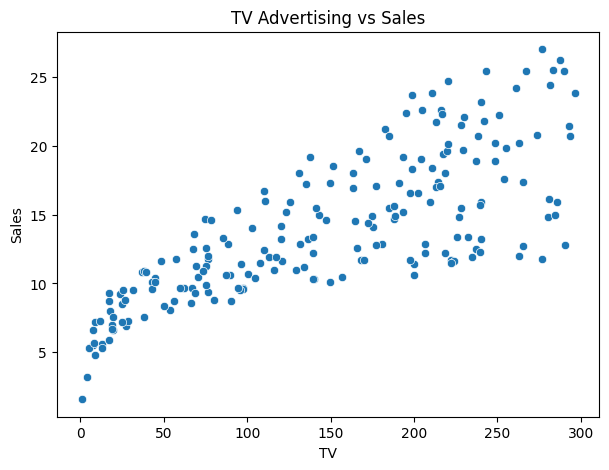

In [8]:
# Relationship between TV advertising and sales

plt.figure(figsize=(7,5))

sns.scatterplot(x='TV', y='Sales', data=df)

plt.title("TV Advertising vs Sales")

plt.show()

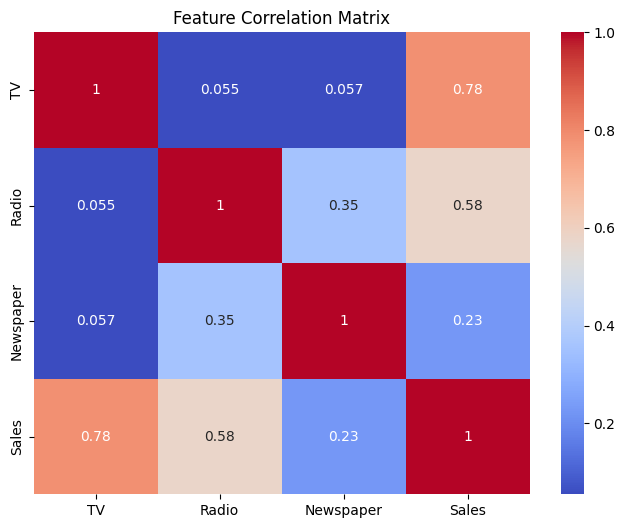

In [9]:
plt.figure(figsize=(8,6))

sns.heatmap(
    df.corr(),
    annot=True,
    cmap='coolwarm'
)

plt.title("Feature Correlation Matrix")

plt.show()

In [11]:
# Advertising channels

X = df[['TV', 'Radio', 'Newspaper']]

# Sales value to predict

y = df['Sales']

In [12]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training Samples:", len(X_train))
print("Testing Samples:", len(X_test))

Training Samples: 160
Testing Samples: 40


In [14]:
# Train Linear Regression Model

from sklearn.linear_model import LinearRegression

sales_model = LinearRegression()

sales_model.fit(X_train, y_train)

print("Model training completed.")

Model training completed.


In [16]:
#Generate Predictions
predictions = sales_model.predict(X_test)

predictions[:5]

array([16.4080242 , 20.88988209, 21.55384318, 10.60850256, 22.11237326])

In [18]:
#Evaluate Model
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

mae = mean_absolute_error(y_test, predictions)
mse = mean_squared_error(y_test, predictions)
r2 = r2_score(y_test, predictions)

print("MAE :", mae)
print("MSE :", mse)
print("R² Score :", r2)

MAE : 1.4607567168117603
MSE : 3.1740973539761033
R² Score : 0.899438024100912


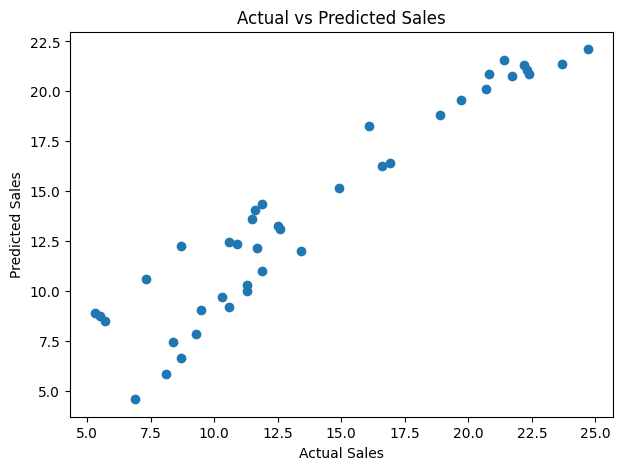

In [19]:
#Actual vs predicted sales

plt.figure(figsize=(7,5))

plt.scatter(y_test, predictions)

plt.xlabel("Actual Sales")
plt.ylabel("Predicted Sales")

plt.title("Actual vs Predicted Sales")

plt.show()

In [20]:
#Feature Importance

importance = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': sales_model.coef_
})

importance

,Feature,Coefficient
0,TV,0.044730
1,Radio,0.189195
2,Newspaper,0.002761


In [21]:
#Test Custom Advertisement Budget

# Example:
# TV = 150
# Radio = 25
# Newspaper = 20

sample = [[150, 25, 20]]

predicted_sales = sales_model.predict(sample)

print("Predicted Sales:", predicted_sales[0])

Predicted Sales: 14.473593601116836


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


In [22]:
import joblib

joblib.dump(
    sales_model,
    "sales_prediction_model.pkl"
)

print("Model saved successfully.")

Model saved successfully.
